### 조원이름: <span style='color:red'>장현진<span>

### 제출자: 곽나현

# CNN Architecture 이해 및 최적화 실습

**실습 시간: 120분 (2시간)** · **구성: 2인 1조**

---

## 실습 목표
1. 기본 CNN(Vanilla Skeleton)의 구조와 학습 과정을 이해한다.
2. 레이어 구성, Optimizer, Activation Function을 직접 바꿔보며 **왜 그렇게 바꿨는지** 논리를 세운다.
3. Train/Test 성능 그래프를 통해 **학습 안정성**과 **Overfitting 완화 여부**를 확인한다.

## 오늘 지켜야 할 약속
- 이것저것 바꿔봤더니 이게 제일 좋았어요 로 끝내지 않기
- **바꾸기 전에 왜 이렇게 바꾸면 좋아질 것 같다는 가설을 먼저 적기**
- 바꾼 후 결과가 가설과 맞았는지, 틀렸다면 왜 그런지 생각해보기

> 이 노트북은 코드를 몰라도 따라올 수 있도록, 실행만 하면 되는 셀과 **직접 수정해야 하는 셀(✏️ 표시)** 을 구분해두었습니다.
코드 전체 구조를 외울 필요는 없습니다. 어떤 것을 바꾸면 어떤 효과가 있는지 메뉴판을 보고 골라 담는다고 생각하세요.

---


## 진행 순서 (총 120분)

| 단계 | 내용 | 시간 |
|---|---|---|
| 0 | 환경설정 & 데이터 로드 | 10분 |
| 1 | 데이터 살펴보기 (EDA) | 10분 |
| 2 | Vanilla CNN(기본 모델) 학습 → 베이스라인 확인 | 20분 |
| 3 | 미션 1: 아키텍처 개선 설계서 작성 (가설 세우기) | 10분 |
| 4 | 미션 2: 아키텍처 개선 & 재학습 (최소 2회 실험) | 45분 |
| 5 | 결과 비교 & 정리 | 15분 |
| 6 | 보고서 작성 및 제출 | 10분 |

시간이 부족하면 미션 4의 실험 횟수를 줄이더라도, **1개의 실험만은 가설→결과→해석까지 끝까지 완성**하는 것을 우선하세요.


---
## 0. 환경설정 & 데이터 로드 (10분)

이 실습은 **Fashion-MNIST** 데이터셋을 사용합니다.
- 28×28 흑백 이미지, 10개 카테고리(티셔츠, 바지, 가방, 신발 등)
- 오픈 데이터셋이며 특정 도메인 지식이 필요 없어 실습에 적합합니다.
- 아래 셀은 **그대로 실행만** 하면 됩니다.


In [66]:
# 필요한 라이브러리 불러오기 (Colab에는 기본 설치되어 있습니다)
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow 버전:", tf.__version__)


TensorFlow 버전: 2.21.0


In [67]:
# 데이터 불러오기
(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 32명이 동시에 실습하는 환경 + CPU 환경을 고려해
# 학습 속도를 위해 데이터 일부만 사용합니다 (성능 자체보다 구조 이해가 목적입니다)
N_TRAIN = 6000   # 전체 60,000장 중 6,000장만 사용
N_TEST = 1500    # 전체 10,000장 중 1,500장만 사용

idx_train = np.random.choice(len(x_train_full), N_TRAIN, replace=False)
idx_test = np.random.choice(len(x_test_full), N_TEST, replace=False)

x_train, y_train = x_train_full[idx_train], y_train_full[idx_train]
x_test, y_test = x_test_full[idx_test], y_test_full[idx_test]

# 정규화 (0~255 -> 0~1) + CNN 입력 형태로 채널 차원 추가 (28,28) -> (28,28,1)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print("Train shape:", x_train.shape, "Test shape:", x_test.shape)


Train shape: (6000, 28, 28, 1) Test shape: (1500, 28, 28, 1)


---
## 1. 데이터 살펴보기 (10분)

본격적인 모델링 전에, 우리가 다룰 데이터가 어떤 모습인지 눈으로 확인합니다.


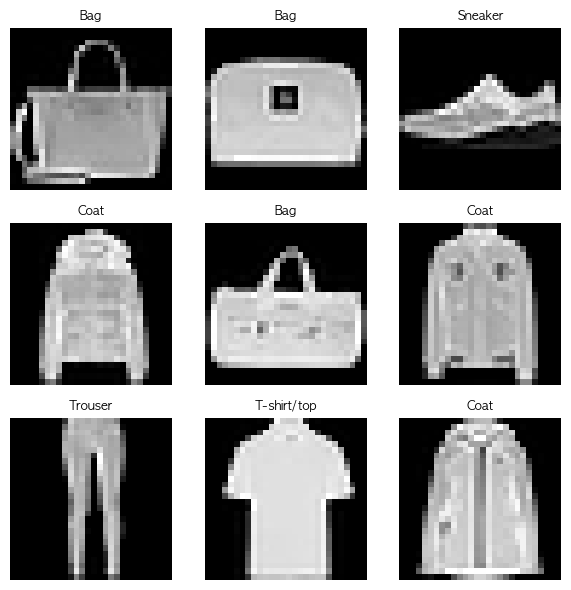

In [68]:
# 샘플 이미지 9장 확인
plt.figure(figsize=(6, 6))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title(class_names[y_train[i]], fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()


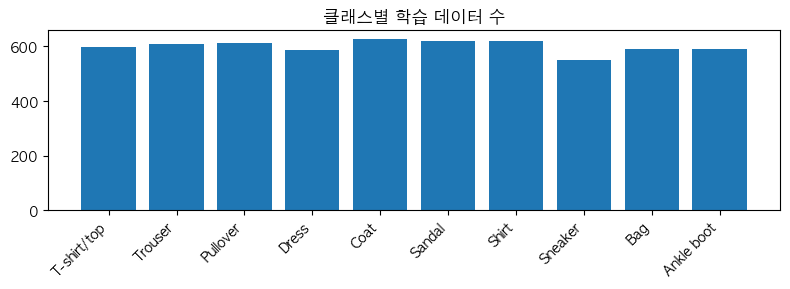

In [69]:
# 클래스별 데이터 개수 확인 (한쪽으로 쏠려있지 않은지 확인하는 습관)
# plt.rcParams["font.family"] = "Malgun Gothic"  # 한글 폰트 설정(윈도우)
plt.rcParams['font.family'] = 'AppleGothic' #( MacOS)
plt.rcParams['axes.unicode_minus'] = False


unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(8, 3))
plt.bar([class_names[u] for u in unique], counts)
plt.xticks(rotation=45, ha="right")
plt.title("클래스별 학습 데이터 수")
plt.tight_layout()
plt.show()


**생각해보기 (답을 적을 필요는 없습니다. 팀원과 짧게 이야기 나눠보세요)**
- 이미지 크기가 28×28×1 이라는 것은 무엇을 의미할까요? (힌트: Part B, Tensor Shape)
- 데이터가 10개 클래스에 고르게 분포되어 있나요?


---
## 2. Vanilla CNN (기본 모델) 학습 (20분)

먼저 **아주 단순한 CNN**을 만들어 학습시켜 보겠습니다. 이 모델을 오늘의 **베이스라인(기준점)** 으로 삼습니다.

### Vanilla Skeleton 구조
```
입력(28,28,1)
 → Conv2D (필터 8개, 3x3, activation='sigmoid')
 → Flatten
 → Dense (10, activation='softmax')
```

일부러 **성능이 잘 안 나오도록** 아주 단순하게 설계했습니다.
- Conv 레이어가 1개뿐이라 특징을 충분히 뽑지 못합니다.
- Activation이 `sigmoid`라 Part B에서 배운 Gradient Vanishing이 발생하기 쉽습니다.
- Pooling, BatchNorm, Dropout 등 어떤 보조 장치도 없습니다.
- Optimizer도 가장 단순한 `SGD`(고정 학습률)를 사용합니다.

여러분의 미션은 이 구조를 **여러분의 논리로 개선**하는 것입니다.


In [70]:
def build_vanilla_model():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(8, (3, 3), activation="sigmoid"),
        layers.Flatten(),
        layers.Dense(10, activation="softmax"),
    ], name="vanilla_cnn")
    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=0.01),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

vanilla_model = build_vanilla_model()
vanilla_model.summary()


Model: "vanilla_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_47 (Conv2D)              │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_23 (Flatten)            │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │        54,090 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,170 (211.60 KB)

 Trainable params: 54,170 (211.60 KB)

 Non-trainable params: 0 (0.00 B)

In [71]:
# 학습을 도와주는 헬퍼 함수 (그대로 실행하세요 - 앞으로 계속 재사용합니다)
history_store = {}  # 실험 결과를 모아두는 저장소

def train_and_record(model, name, epochs=15, batch_size=64, callbacks=None):
    print(f"\n=== [{name}] 학습 시작 ===")
    history = model.fit(
        x_train, y_train,
        validation_data=(x_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks or [],
        verbose=0,
    )
    history_store[name] = history.history
    train_acc = history.history["accuracy"][-1]
    val_acc = history.history["val_accuracy"][-1]
    gap = train_acc - val_acc
    print(f"[{name}] 최종 Train Acc: {train_acc:.3f} | Test Acc: {val_acc:.3f} | 격차(Overfitting 정도): {gap:.3f}")
    return history

def plot_history(names=None):
    # 저장된 실험들의 Loss/Accuracy 곡선을 한 화면에 비교
    names = names or list(history_store.keys())
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    all_names = list(history_store.keys())
    color_map = {name: plt.cm.tab10(index % 10) for index, name in enumerate(all_names)}
    for name in names:
        color = color_map[name]  # 전체 누적 그래프와 같은 모델 색상 유지
        h = history_store[name]
        marker_step = max(1, len(h["loss"]) // 8)
        axes[0].plot(h["loss"], color=color, linewidth=2.2, marker="o", markevery=marker_step, label=f"{name} (Train)")
        axes[0].plot(h["val_loss"], color=color, linewidth=2.2, linestyle="--", marker="x", markevery=marker_step, label=f"{name} (Test)")
        axes[1].plot(h["accuracy"], color=color, linewidth=2.2, marker="o", markevery=marker_step, label=f"{name} (Train)")
        axes[1].plot(h["val_accuracy"], color=color, linewidth=2.2, linestyle="--", marker="x", markevery=marker_step, label=f"{name} (Test)")
    axes[0].set_title("Loss Comparison", fontsize=14, fontweight="bold")
    axes[1].set_title("Accuracy Comparison", fontsize=14, fontweight="bold")
    for axis in axes:
        axis.set_xlabel("Epoch")
        axis.grid(True, alpha=0.3)
        axis.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

def summary_table():
    # 실험별 최종 성능을 표로 요약
    print(f"{'실험명':<20}{'Train Acc':>12}{'Test Acc':>12}{'격차':>10}")
    for name, h in history_store.items():
        tr, va = h["accuracy"][-1], h["val_accuracy"][-1]
        print(f"{name:<20}{tr:>12.3f}{va:>12.3f}{tr-va:>10.3f}")



=== [1_Vanilla_Baseline] 학습 시작 ===
[1_Vanilla_Baseline] 최종 Train Acc: 0.753 | Test Acc: 0.757 | 격차(Overfitting 정도): -0.005


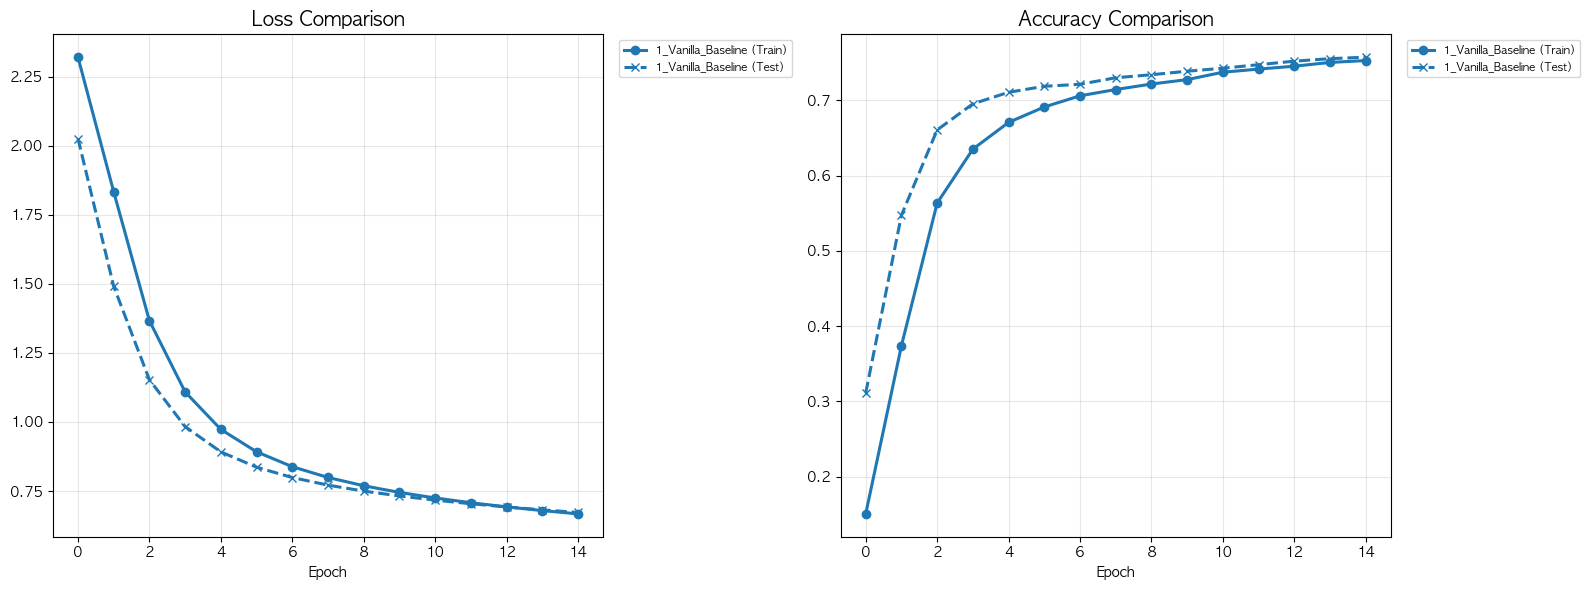

In [72]:
# 베이스라인 학습 (약 1~2분 소요)
train_and_record(vanilla_model, "1_Vanilla_Baseline", epochs=15)
plot_history(["1_Vanilla_Baseline"])


**베이스라인 결과를 보고 확인할 것**
- Train Accuracy와 Test Accuracy의 격차가 큰가요, 작은가요?
- Loss 그래프가 잘 떨어지고 있나요, 아니면 정체되어 있나요? (`sigmoid` + 얕은 구조의 한계일 수 있습니다)

이 두 가지 관찰이 바로 **다음 단계에서 "무엇을 왜 바꿀지"의 출발점**입니다.


---
## 3. 미션 1: 아키텍처 개선 설계서 작성 (10분)

바로 코드를 고치지 말고, 먼저 아래 표를 **팀원과 상의해서 채워보세요.**
(이 표의 내용은 이후 제출할 보고서에 그대로 활용됩니다.)

| 항목 | 여러분의 계획 |
|---|---|
| 베이스라인에서 가장 문제라고 생각하는 부분은? | Vanilla CNN은 Conv 레이어가 1개이고 필터도 8개라 충분한 특징을 추출하기 부족하다. 또한 sigmoid를 사용하여 층이 깊어질 경우 Gradient Vanishing으로 학습이 원활하지 않을 수 있고, SGD의 고정된 학습률으로는 파라미터별 세밀한 조정이 어렵다. |
| 그래서 무엇을 바꿀 것인가? | Conv 레이어를 추가하고 필터를 `8 → 16 → 32`로 늘린다. MaxPooling2D를 추가하고 Activation Function을 `sigmoid`에서 `relu`로, Optimizer를 `SGD`에서 `Adam`으로 변경한다. BatchNormalization을 추가하고 `batch_size`와 `epochs`를 조정하며, Dropout과 EarlyStopping도 적용한다. |
| 왜 그 변경이 효과가 있을 거라 예상하는가? (가설) | Conv 레이어를 더 깊게 쌓고 필터 수를 늘리면 더 다양하고 복잡한 특징을 추출할 수 있을 것이다. MaxPooling2D는 중요한 특징을 보존하면서 노이즈와 연산량을 줄일 것이다. ReLU는 sigmoid의 Gradient Vanishing 문제를 완화하고, Adam은 파라미터별 학습률을 적응적으로 조절하여 성능을 향상시킬 것이다. BatchNormalization은 Conv 출력의 분포를 안정화하고, batch size·epochs 조정과 Dropout·EarlyStopping은 충분한 학습을 진행하면서 과적합을 줄일 것이다.|

### 개선 메뉴판 (아래에서 골라 조합해보세요)

**A. 레이어 구조**
- Conv2D 레이어 추가 (더 깊게 특징 추출)
- Conv2D 필터 개수 늘리기 (8 → 16, 32 …)
- MaxPooling2D 추가 (연산량 감소, 위치 변화에 강건해짐)
- Dropout 추가 (과적합 방지)
- BatchNormalization 추가 (학습 안정화, Part B 참고)

**B. Activation Function**
- `sigmoid` → `relu` (Gradient Vanishing 완화)

**C. Optimizer**
- `SGD` → `Adam` (방향+보폭을 자동으로 조절, Part B 참고)

**D. 학습 전략**
- `epochs` 조절 (너무 적으면 학습 부족, 너무 많으면 과적합)
- `batch_size` 조절

> 한 번에 모든 것을 바꾸지 마세요. 무엇을 바꿔서 무엇이 좋아졌는지 알 수 없게 됩니다. **1~2개씩 바꿔가며 비교**하는 것이 좋은 실험입니다.


---
## 4. 미션 2: 아키텍처 개선 & 재학습 (45분)

Vanilla CNN을 기준으로 아래 6개 실험을 비교합니다.

| 구분 | 핵심 변경 | Activation | Optimizer |
|---|---|---|---|
| Vanilla CNN | Conv2D(8) 1개 | sigmoid | SGD |
| 실험 1 | Conv2D(8) 3개 | sigmoid | SGD |
| 실험 2 | MaxPooling2D 추가 | sigmoid | SGD |
| 실험 3 | Conv 필터 8 → 16 → 32 | sigmoid | SGD |
| 실험 4 | MaxPooling2D + Adam | sigmoid | Adam |
| 실험 5 | Conv 8 → 16 → 32, Dense 32 → 16 | ReLU | Adam |
| 실험 6 | BatchNormalization + MaxPooling2D | sigmoid | Adam |
| 실험 7 | Conv 블록 + BatchNorm + Pooling + Dropout + EarlyStopping | ReLU | Adam + 학습률 감소 |

**Vanilla CNN 학습 후 실험 1~7을 순서대로 실행하세요.**


In [73]:
# ==============================================================================
# [실험 1] Conv 레이어 증가: 필터 8 → 8 → 8, sigmoid, SGD
# ==============================================================================
def build_improved_model_v1():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(8, (3, 3), activation="sigmoid"),
        layers.Conv2D(8, (3, 3), activation="sigmoid"),
        layers.Conv2D(8, (3, 3), activation="sigmoid"),
        layers.Flatten(),
        layers.Dense(64, activation="sigmoid"),
        layers.Dense(10, activation="softmax"),
    ], name="improved_v1")

    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=0.01),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

improved_model_v1 = build_improved_model_v1()
improved_model_v1.summary()


Model: "improved_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_48 (Conv2D)              │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 24, 24, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 22, 22, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_24 (Flatten)            │ (None, 3872)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 64)             │       247,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 249,770 (975.66 KB)

 Trainable params: 249,770 (975.66 KB)

 Non-trainable params: 0 (0.00 B)


=== [2_Experiment_1_Conv_8_8_8] 학습 시작 ===
[2_Experiment_1_Conv_8_8_8] 최종 Train Acc: 0.099 | Test Acc: 0.105 | 격차(Overfitting 정도): -0.006


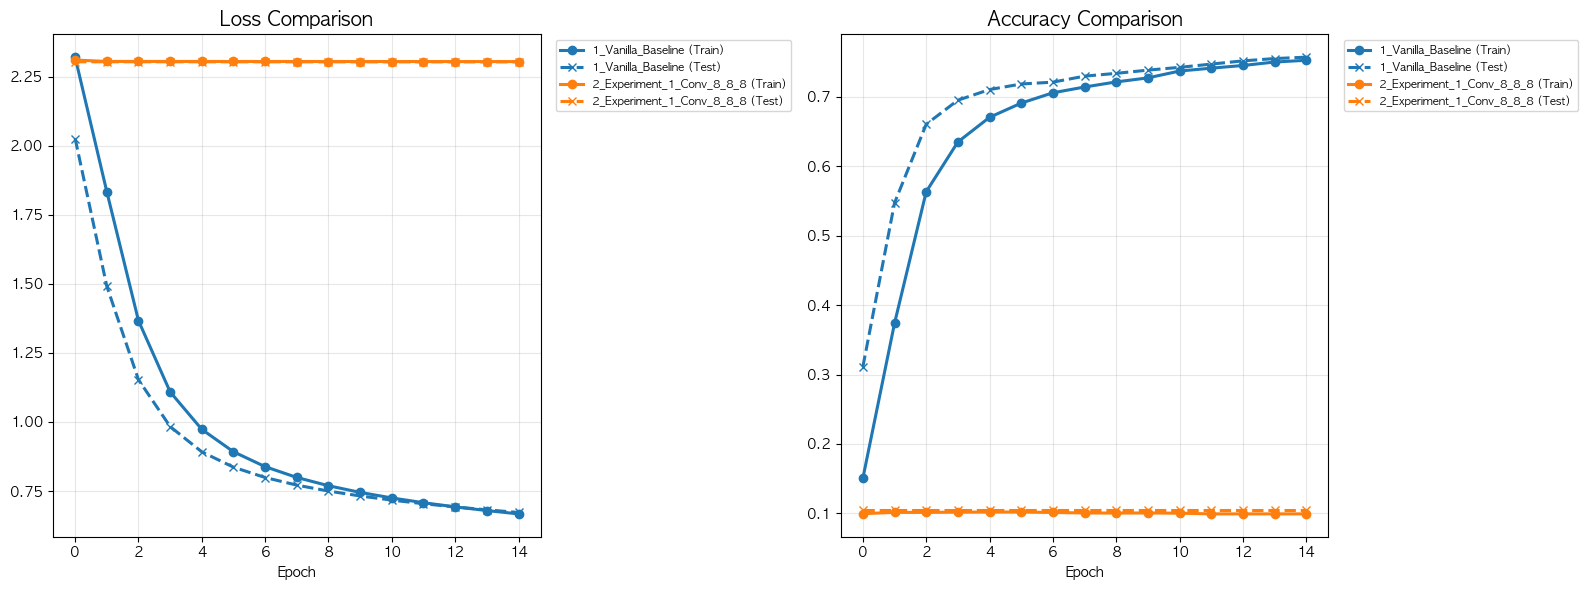

In [74]:
# ========================== 실험 1 학습 ==========================
train_and_record(improved_model_v1, "2_Experiment_1_Conv_8_8_8", epochs=15, batch_size=64)
plot_history(["1_Vanilla_Baseline", "2_Experiment_1_Conv_8_8_8"])


**실험 1 결과를 베이스라인과 비교해서 팀원과 이야기해보세요**
- 가설(왜 좋아질 것이라 예상했는지)과 실제 결과가 일치했나요?
- Train/Test 격차(Overfitting 정도)는 베이스라인보다 좋아졌나요, 나빠졌나요?

---

## 🧪 실험 2 — Vanilla CNN에 MaxPooling2D만 추가
(예: 실험 1에서 activation을 바꿨다면, 실험 2에서는 BatchNorm이나 Optimizer를 바꿔보는 식)


In [75]:
# ==============================================================================
# [실험 2] Vanilla CNN에 MaxPooling2D만 추가
# ==============================================================================
def build_improved_model_v2():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(8, (3, 3), activation="sigmoid"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(10, activation="softmax"),
    ], name="improved_v2")

    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=0.01),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

improved_model_v2 = build_improved_model_v2()
improved_model_v2.summary()


Model: "improved_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_51 (Conv2D)              │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_25 (Flatten)            │ (None, 1352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 10)             │        13,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,610 (53.16 KB)

 Trainable params: 13,610 (53.16 KB)

 Non-trainable params: 0 (0.00 B)


=== [3_Experiment_2_MaxPooling] 학습 시작 ===
[3_Experiment_2_MaxPooling] 최종 Train Acc: 0.736 | Test Acc: 0.724 | 격차(Overfitting 정도): 0.012


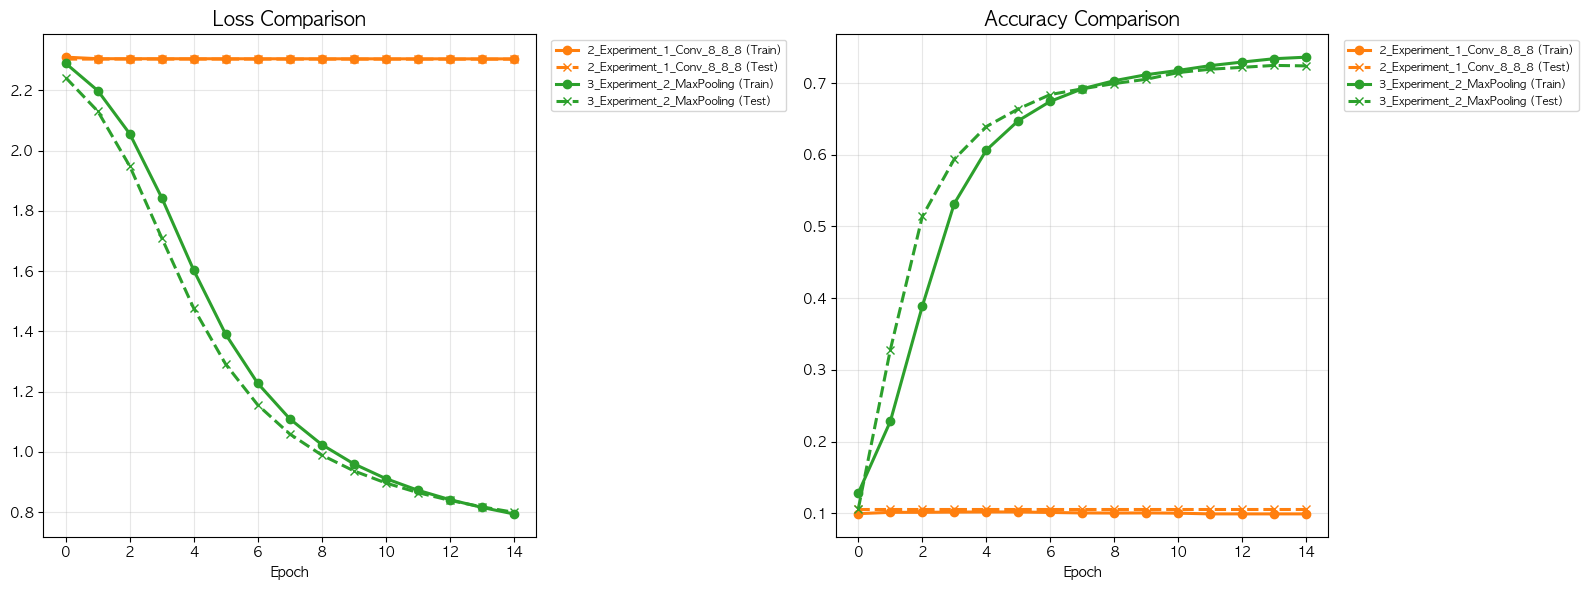

In [76]:
# ========================== 실험 2 학습 ==========================
train_and_record(improved_model_v2, "3_Experiment_2_MaxPooling", epochs=15, batch_size=64)
plot_history(["2_Experiment_1_Conv_8_8_8", "3_Experiment_2_MaxPooling"])  # 실험 1과 실험 2 비교


In [77]:
# ==============================================================================
# [실험 3] Conv 필터 증가: 8 → 16 → 32, sigmoid, SGD
# ==============================================================================
def build_improved_model_v3():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(8, (3, 3), activation="sigmoid"),
        layers.Conv2D(16, (3, 3), activation="sigmoid"),
        layers.Conv2D(32, (3, 3), activation="sigmoid"),
        layers.Flatten(),
        layers.Dense(64, activation="sigmoid"),
        layers.Dense(10, activation="softmax"),
    ], name="improved_v3")

    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=0.01),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

improved_model_v3 = build_improved_model_v3()
improved_model_v3.summary()


Model: "improved_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_52 (Conv2D)              │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 24, 24, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 22, 22, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_26 (Flatten)            │ (None, 15488)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 64)             │       991,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 997,834 (3.81 MB)

 Trainable params: 997,834 (3.81 MB)

 Non-trainable params: 0 (0.00 B)


=== [4_Experiment_3_Conv_8_16_32] 학습 시작 ===
[4_Experiment_3_Conv_8_16_32] 최종 Train Acc: 0.099 | Test Acc: 0.105 | 격차(Overfitting 정도): -0.006


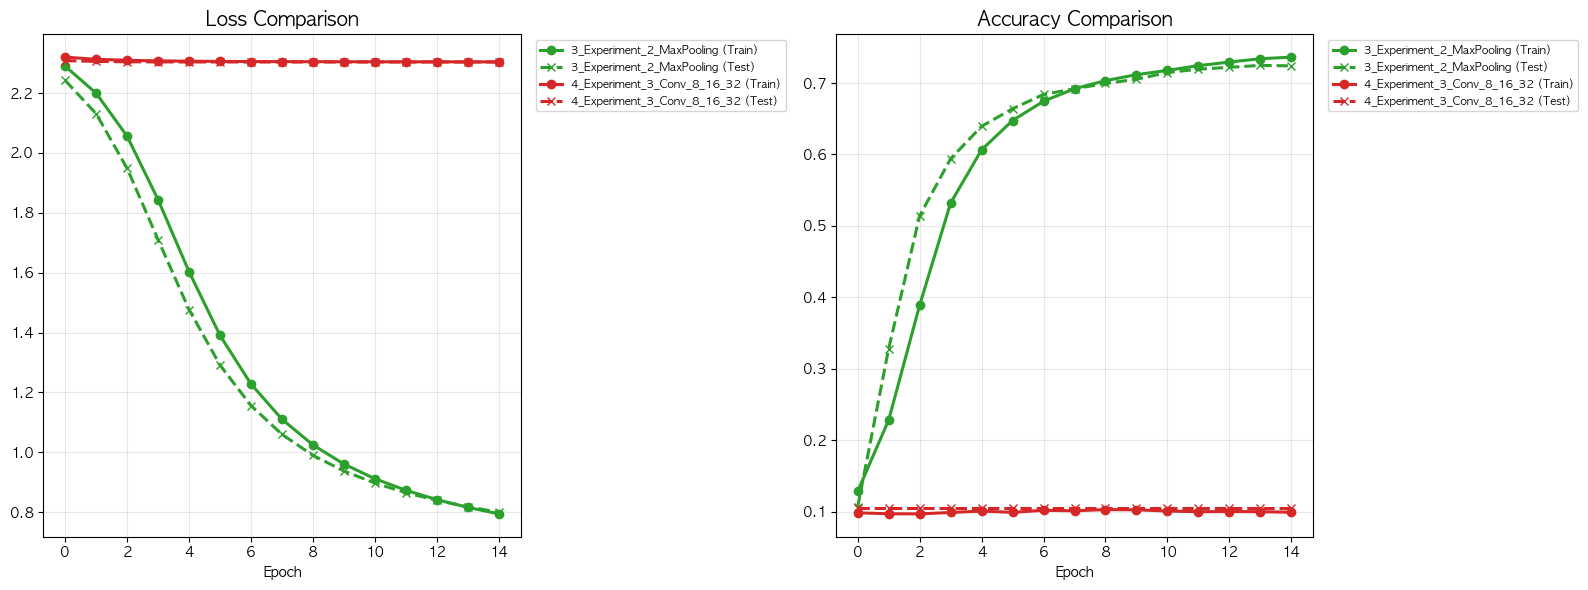

In [78]:
# ========================== 실험 3 학습 ==========================
train_and_record(improved_model_v3, "4_Experiment_3_Conv_8_16_32", epochs=15, batch_size=64)
plot_history(["3_Experiment_2_MaxPooling", "4_Experiment_3_Conv_8_16_32"])  # 실험 2와 실험 3 비교


In [79]:
# ==============================================================================
# [실험 4] MaxPooling2D 구조에서 Optimizer를 Adam으로 변경
# ==============================================================================
def build_improved_model_v4():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(8, (3, 3), activation="sigmoid"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(10, activation="softmax"),
    ], name="improved_v4")

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

improved_model_v4 = build_improved_model_v4()
improved_model_v4.summary()


Model: "improved_v4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_55 (Conv2D)              │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_27 (Flatten)            │ (None, 1352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 10)             │        13,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,610 (53.16 KB)

 Trainable params: 13,610 (53.16 KB)

 Non-trainable params: 0 (0.00 B)


=== [5_Experiment_4_Adam_MaxPooling] 학습 시작 ===
[5_Experiment_4_Adam_MaxPooling] 최종 Train Acc: 0.805 | Test Acc: 0.804 | 격차(Overfitting 정도): 0.001


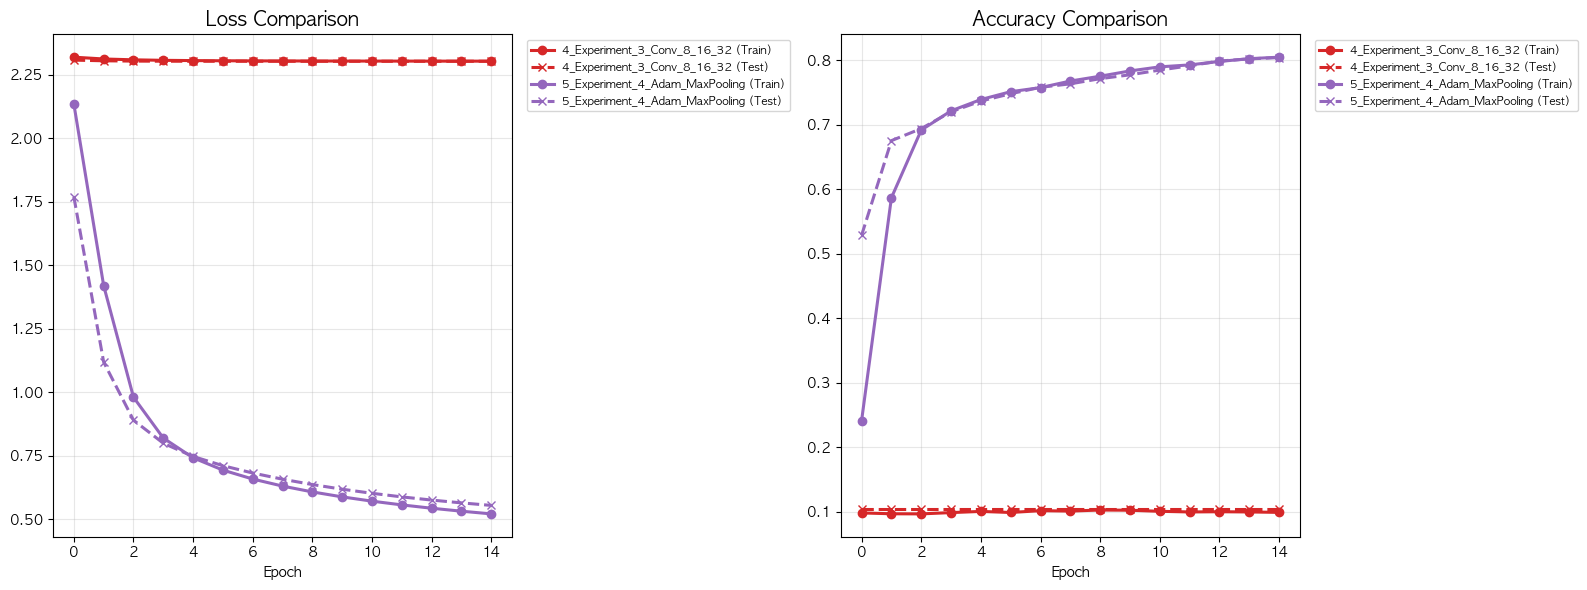

In [80]:
# ========================== 실험 4 학습 ==========================
train_and_record(improved_model_v4, "5_Experiment_4_Adam_MaxPooling", epochs=15, batch_size=64)
plot_history(["4_Experiment_3_Conv_8_16_32", "5_Experiment_4_Adam_MaxPooling"])  # 실험 3과 실험 4 비교


In [81]:
# ==============================================================================
# [실험 5] Conv 8 → 16 → 32, Dense 32 → 16, ReLU, Adam
# ==============================================================================
def build_improved_model_v5():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(8, (3, 3), activation="relu"),
        layers.Conv2D(16, (3, 3), activation="relu"),
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.Flatten(),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ], name="improved_v5")

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

improved_model_v5 = build_improved_model_v5()
improved_model_v5.summary()


Model: "improved_v5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_56 (Conv2D)              │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 24, 24, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 22, 22, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_28 (Flatten)            │ (None, 15488)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 32)             │       495,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 502,234 (1.92 MB)

 Trainable params: 502,234 (1.92 MB)

 Non-trainable params: 0 (0.00 B)


=== [6_Experiment_5_ReLU_Adam] 학습 시작 ===
[6_Experiment_5_ReLU_Adam] 최종 Train Acc: 0.959 | Test Acc: 0.856 | 격차(Overfitting 정도): 0.103


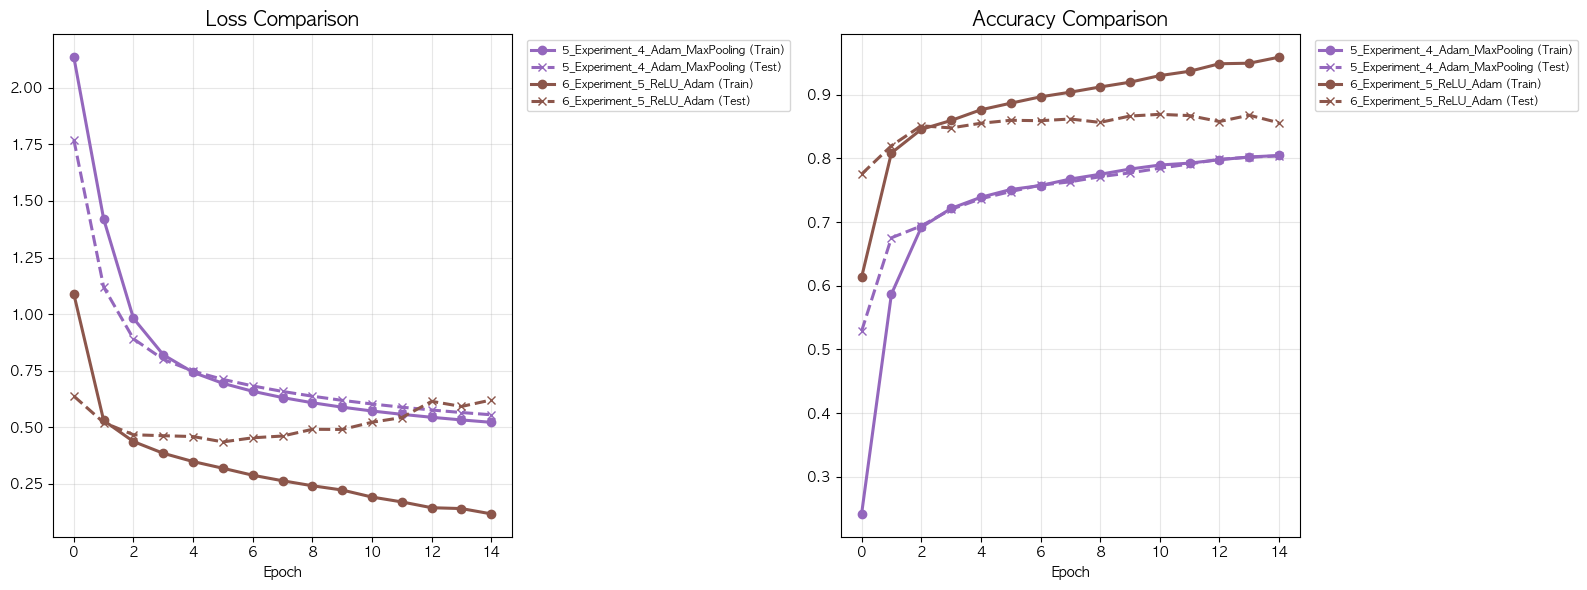

In [82]:
# ========================== 실험 5 학습 ==========================
train_and_record(improved_model_v5, "6_Experiment_5_ReLU_Adam", epochs=15, batch_size=64)
plot_history(["5_Experiment_4_Adam_MaxPooling", "6_Experiment_5_ReLU_Adam"])  # 실험 4와 실험 5 비교


In [83]:
# ==============================================================================
# [실험 6] BatchNormalization + MaxPooling2D, Adam
# ==============================================================================
def build_improved_model_v6():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(8, (3, 3), activation="sigmoid"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(10, activation="softmax"),
    ], name="improved_v6")

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

improved_model_v6 = build_improved_model_v6()
improved_model_v6.summary()


Model: "improved_v6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_59 (Conv2D)              │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 26, 26, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_29 (Flatten)            │ (None, 1352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 10)             │        13,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,642 (53.29 KB)

 Trainable params: 13,626 (53.23 KB)

 Non-trainable params: 16 (64.00 B)


=== [7_Experiment_6_BatchNorm] 학습 시작 ===
[7_Experiment_6_BatchNorm] 최종 Train Acc: 0.976 | Test Acc: 0.851 | 격차(Overfitting 정도): 0.125


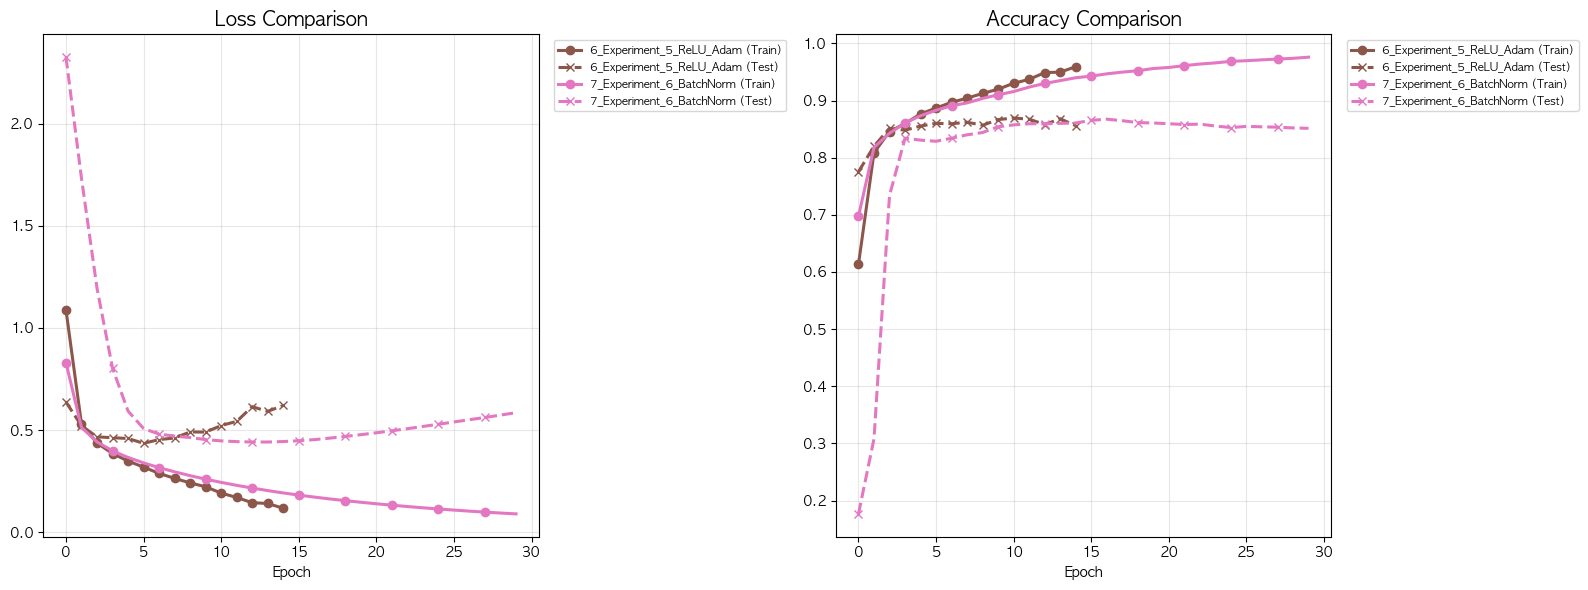

In [84]:
# ========================== 실험 6 학습 ==========================
train_and_record(improved_model_v6, "7_Experiment_6_BatchNorm", epochs=30, batch_size=64)
plot_history(["6_Experiment_5_ReLU_Adam", "7_Experiment_6_BatchNorm"])  # 실험 5와 실험 6 비교


---
## 🧪 실험 7 — 아키텍처·규제화·학습 전략 종합 개선

실험 7에서는 다음 요소를 함께 적용합니다.

- **Conv 레이어 변경:** `32 → 32 → 64 → 64`로 필터를 늘려 단순한 특징에서 복잡한 특징까지 추출
- **ReLU:** sigmoid보다 기울기 소실이 적어 깊은 모델의 학습을 도움
- **BatchNormalization:** 각 Conv 블록의 출력 분포를 안정화
- **MaxPooling2D:** 특징 맵의 크기와 연산량을 줄임
- **Dropout:** Conv 블록과 Dense 레이어의 과적합을 완화
- **EarlyStopping:** `val_loss`가 5 epoch 동안 개선되지 않으면 조기 종료하고 최적 가중치 복원
- **ReduceLROnPlateau:** `val_loss`가 2 epoch 동안 개선되지 않으면 학습률을 절반으로 감소
- **학습 조건:** 최대 `epochs=50`, `batch_size=64` (조기 종료로 50 epoch 전에 끝날 수 있음)
---


In [85]:
# ==============================================================================
# [실험 7] Conv 블록 + BatchNorm + Pooling + Dropout 종합 개선 모델
# ==============================================================================
def build_improved_model_v7():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.30),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.50),
        layers.Dense(10, activation="softmax"),
    ], name="improved_v7")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

improved_model_v7 = build_improved_model_v7()
improved_model_v7.summary()


Model: "improved_v7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_60 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_30 (Flatten)            │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 469,098 (1.79 MB)

 Trainable params: 468,458 (1.79 MB)

 Non-trainable params: 640 (2.50 KB)


=== [8_Experiment_7_Complete_Strategy] 학습 시작 ===

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 19: early stopping
Restoring model weights from the end of the best epoch: 14.
[8_Experiment_7_Complete_Strategy] 최종 Train Acc: 0.958 | Test Acc: 0.894 | 격차(Overfitting 정도): 0.064
실험 7 실제 학습 Epoch: 19


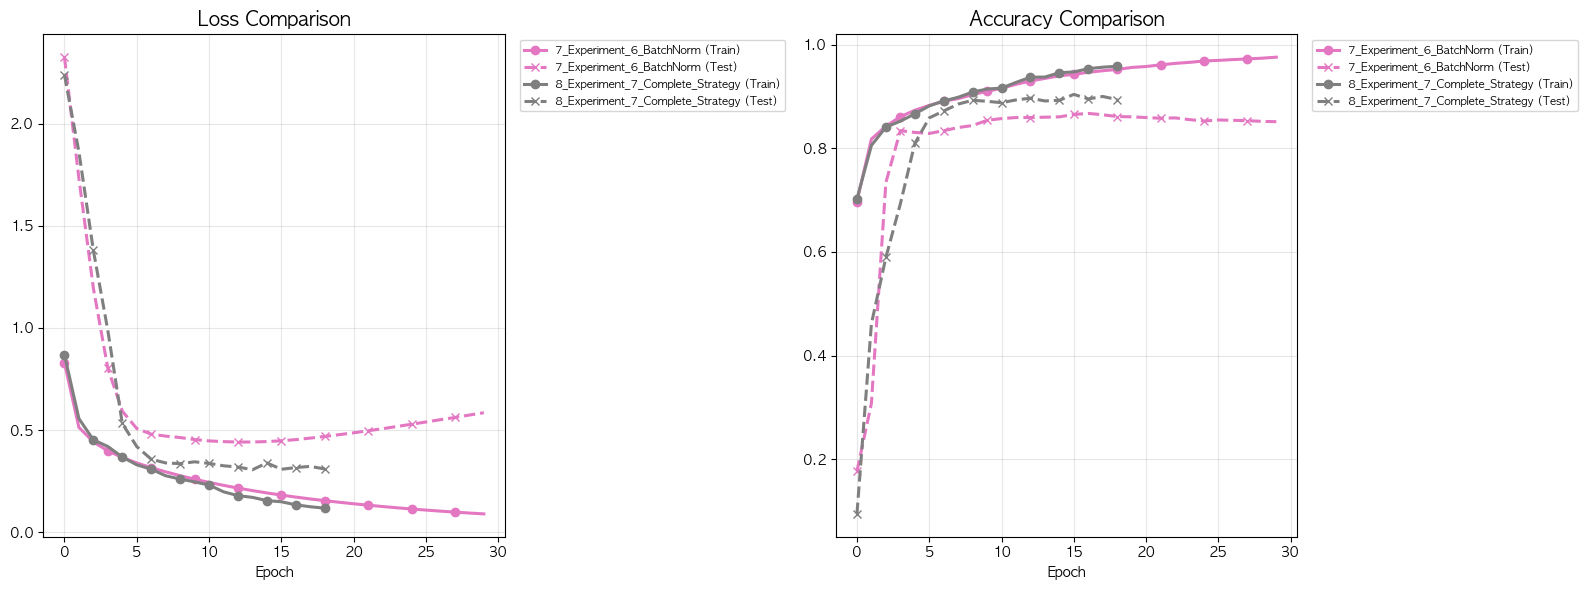

In [86]:
# ========================== 실험 7 학습 전략 ==========================
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1,
)

history_v7 = train_and_record(
    improved_model_v7,
    "8_Experiment_7_Complete_Strategy",
    epochs=50,
    batch_size=64,
    callbacks=[early_stopping, reduce_lr],
)
print(f"실험 7 실제 학습 Epoch: {len(history_v7.history['loss'])}")
plot_history(["7_Experiment_6_BatchNorm", "8_Experiment_7_Complete_Strategy"])  # 실험 6과 실험 7 비교


---
## 📊 Vanilla CNN + 실험 1~7 전체 누적 그래프

아래 그래프에서 베이스라인과 모든 실험의 Loss, Accuracy를 한 번에 비교합니다.
---


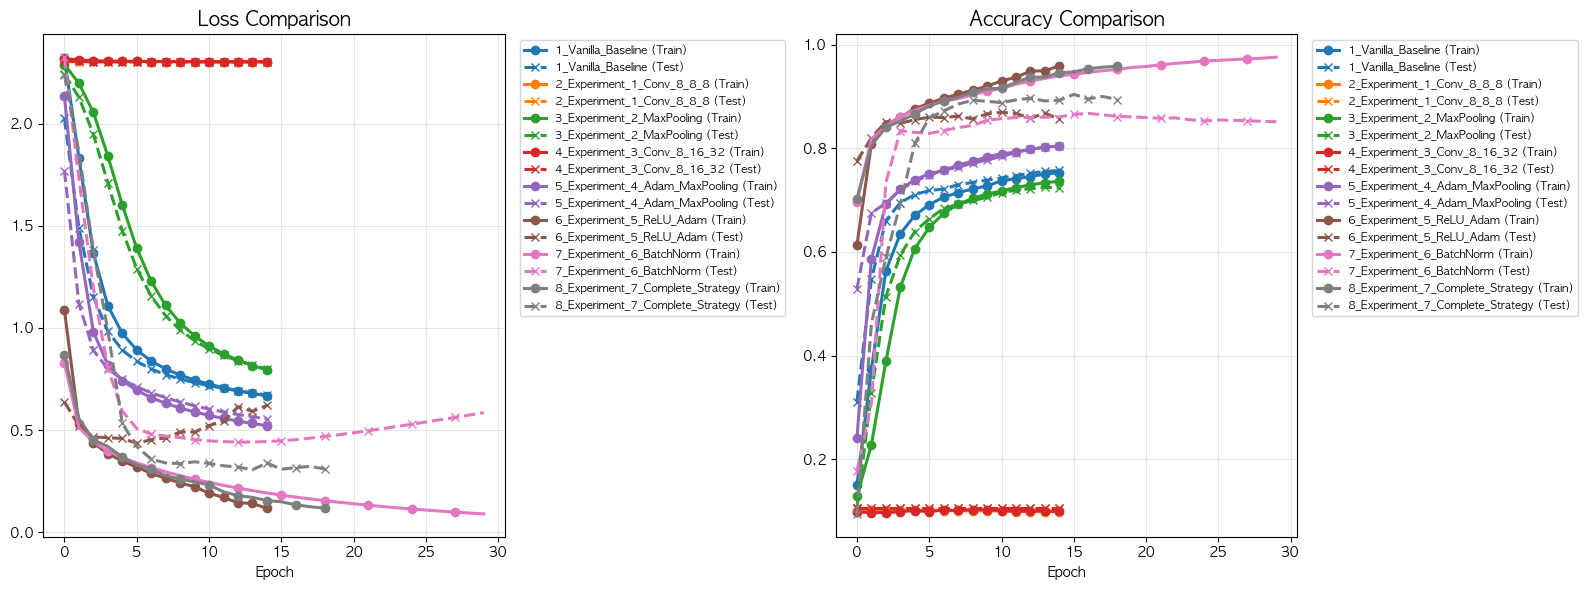

In [87]:
# Vanilla CNN과 실험 1~7 전체 누적 비교
plot_history([
    "1_Vanilla_Baseline",
    "2_Experiment_1_Conv_8_8_8",
    "3_Experiment_2_MaxPooling",
    "4_Experiment_3_Conv_8_16_32",
    "5_Experiment_4_Adam_MaxPooling",
    "6_Experiment_5_ReLU_Adam",
    "7_Experiment_6_BatchNorm",
    "8_Experiment_7_Complete_Strategy",
])


---
## 5. 결과 비교 & 정리 (15분)


In [88]:
# 지금까지의 모든 실험 결과를 표로 요약
summary_table()


실험명                    Train Acc    Test Acc        격차
1_Vanilla_Baseline         0.753       0.757    -0.005
2_Experiment_1_Conv_8_8_8       0.099       0.105    -0.006
3_Experiment_2_MaxPooling       0.736       0.724     0.012
4_Experiment_3_Conv_8_16_32       0.099       0.105    -0.006
5_Experiment_4_Adam_MaxPooling       0.805       0.804     0.001
6_Experiment_5_ReLU_Adam       0.959       0.856     0.103
7_Experiment_6_BatchNorm       0.976       0.851     0.125
8_Experiment_7_Complete_Strategy       0.958       0.894     0.064


**정리 질문 (보고서에 활용하세요)**
1. 가장 성능(Test Accuracy)이 좋았던 실험은 무엇인가요?
2. 가장 **Train/Test 격차가 작았던(=안정적인)** 실험은 무엇인가요? (성능이 가장 좋은 실험과 같지 않을 수도 있습니다.)
3. 여러분이 세웠던 가설 중 **예상과 다르게 나온 결과**가 있었나요? 왜 그랬을 것 같나요?
4. 만약 시간이 더 있다면, 다음에는 무엇을 시도해보고 싶나요?

> 이 질문들에 대한 답은 **"이게 제일 좋았어요"로 끝나면 안 됩니다.** 왜 그런 결과가 나왔는지에 대한 여러분의 해석이 포인트입니다.


---
## 6. 제출 안내 (10분)

### 제출물 (2가지)
1. **이 노트북 파일** (`.ipynb`) — 실행 결과(그래프 포함)가 모두 남아있는 상태로 저장 후 제출
   - `파일 > 다운로드 > .ipynb 다운로드` (Colab 기준)
2. **간단 보고서** (`.pdf`, 별도 제공된 템플릿 사용)
   - 베이스라인 구조/성능, 실험별 가설·결과·해석, 최종 결론을 포함

### 평가 기준 (참고)
| 항목 | 평가 내용 | 배점 |
|---|---|---|
| 아키텍처 개선 논리 | 개선 목표의 명확성, 설계 판단의 논리성 | 20 |
| 아키텍처 개선 설계 타당성 | 목적에 맞는 Layer/Optimizer/Activation 선정 | 15 |
| 학습 안정성 및 일반화 | Train/Test 성능 안정성(그래프), Overfitting 완화 여부 | 15 |

**수고하셨습니다.**
